In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/03_visualisation/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

print('Racine projet :', ROOT)
df = pd.read_parquet(DATA_RAW / '100102-0.parquet')

Racine projet : \\FS-SOP\Staff-CMA\yzouarhi\Bureau\Data\FlexiMax


In [2]:

print("="*60)
print("Dimensions du dataset")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("Liste des colonnes")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

print("\n" + "="*60)
print("Types des variables")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("Nombre de valeurs manquantes")
print("="*60)
print(df.isna().sum())

print("\n" + "="*60)
print("Aperçu des données")
print("="*60)
print(df.head())
print ("\n" + "="*60 + "\n")


Dimensions du dataset
(35040, 192)

Liste des colonnes
  1. bldg_id
  2. timestamp
  3. in.sqft
  4. out.electricity.ceiling_fan.energy_consumption..kwh
  5. out.electricity.clothes_dryer.energy_consumption..kwh
  6. out.electricity.clothes_washer.energy_consumption..kwh
  7. out.electricity.cooling.energy_consumption..kwh
  8. out.electricity.cooling_fans_pumps.energy_consumption..kwh
  9. out.electricity.dishwasher.energy_consumption..kwh
 10. out.electricity.ev_charging.energy_consumption..kwh
 11. out.electricity.freezer.energy_consumption..kwh
 12. out.electricity.heating.energy_consumption..kwh
 13. out.electricity.heating_fans_pumps.energy_consumption..kwh
 14. out.electricity.heating_hp_bkup.energy_consumption..kwh
 15. out.electricity.heating_hp_bkup_fa.energy_consumption..kwh
 16. out.electricity.hot_water.energy_consumption..kwh
 17. out.electricity.hot_water_solar_th.energy_consumption..kwh
 18. out.electricity.lighting_exterior.energy_consumption..kwh
 19. out.electricity.

In [3]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
bldg_id,35040.0,100102.0,100102.0,100102.0,100102.0,100102.0,100102.0,0.0
timestamp,35040,2018-07-02 12:07:30,2018-01-01 00:15:00,2018-04-02 06:11:15,2018-07-02 12:07:30,2018-10-01 18:03:45,2019-01-01 00:00:00,NaN
in.sqft,35040.0,1228.0,1228.0,1228.0,1228.0,1228.0,1228.0,0.0
out.electricity.ceiling_fan.energy_consumption..kwh,35040.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
out.electricity.clothes_dryer.energy_consumption..kwh,35040.0,0.031618,0.0,0.0,0.0,0.0,2.4729,0.257266
...,...,...,...,...,...,...,...,...
out.schedules.plug_loads_other,35040.0,0.601744,0.464,0.562,0.571,0.623,1.0,0.065635
out.schedules.plug_loads_tv,35040.0,0.133549,0.0151,0.0181,0.0732,0.165,1.0,0.160484
out.schedules.power_outage,35040.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
out.schedules.pre_peak_period,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Conversion de la date
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Variable principale
target = "out.electricity.total.energy_consumption..kwh"

# Colonnes temporelles
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month
df["date"] = df["timestamp"].dt.date



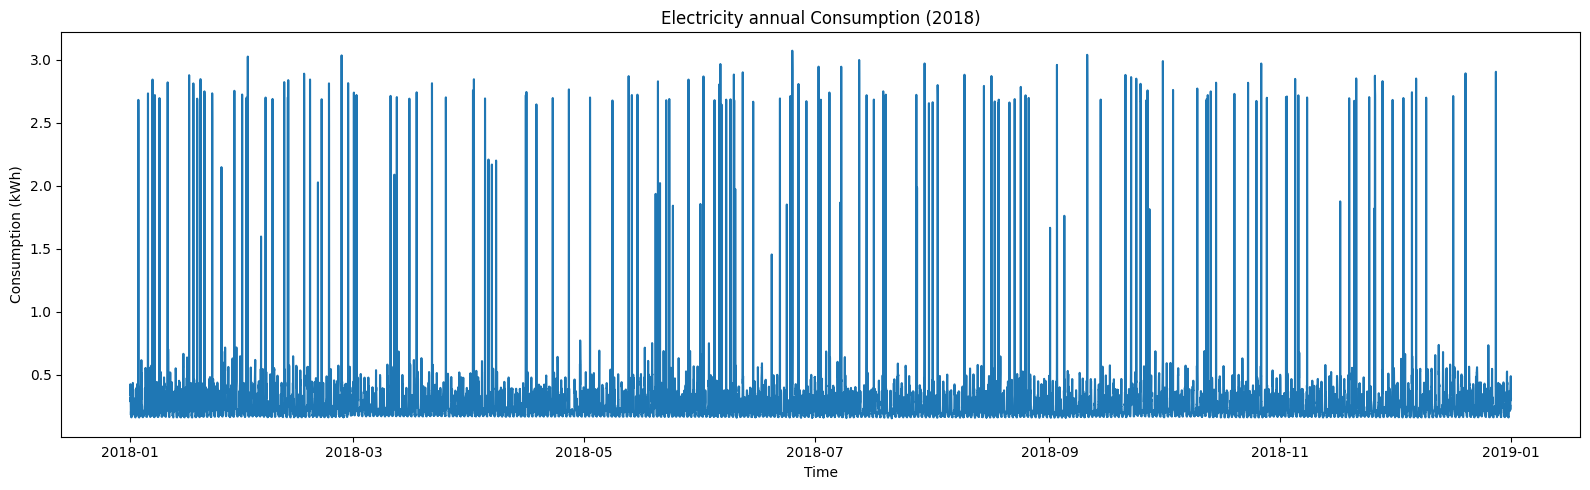

In [8]:
plt.figure(figsize=(16,5))

plt.plot(df["timestamp"], df[target])

plt.title("Electricity annual Consumption (2018)")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")

plt.tight_layout()
plt.show()


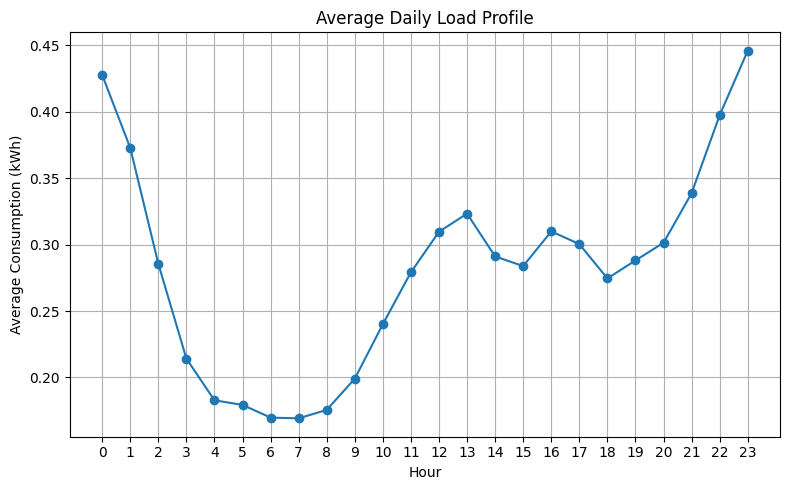

In [9]:
hourly = df.groupby("hour")[target].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly.index, hourly.values, marker="o")

plt.xticks(range(24))

plt.title("Average Daily Load Profile")
plt.xlabel("Hour")
plt.ylabel("Average Consumption (kWh)")

plt.grid(True)

plt.tight_layout()
plt.show()
